In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

df = pd.read_csv('../data/telco_churn.csv')
print("Shape:", df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# Data types overview
print(df.info())
print("\n" + "="*50 + "\n")

# Missing values
print("Missing values per column:")
print(df.isnull().sum())
print("\n" + "="*50 + "\n")

# Duplicate rows
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate customerIDs:", df['customerID'].duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [3]:
# Find rows where TotalCharges is blank/whitespace
blank_mask = df['TotalCharges'].str.strip() == ''
print("Rows with blank TotalCharges:", blank_mask.sum())
print(df[blank_mask][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']])

Rows with blank TotalCharges: 11
      customerID  tenure  MonthlyCharges TotalCharges
488   4472-LVYGI       0           52.55             
753   3115-CZMZD       0           20.25             
936   5709-LVOEQ       0           80.85             
1082  4367-NUYAO       0           25.75             
1340  1371-DWPAZ       0           56.05             
3331  7644-OMVMY       0           19.85             
3826  3213-VVOLG       0           25.35             
4380  2520-SGTTA       0           20.00             
5218  2923-ARZLG       0           19.70             
6670  4075-WKNIU       0           73.35             
6754  2775-SEFEE       0           61.90             


In [4]:
# Convert TotalCharges to numeric, coercing blanks to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].str.strip(), errors='coerce')

# Fill the resulting NaNs (the 11 zero-tenure customers) with 0
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Verify
print("Dtype now:", df['TotalCharges'].dtype)
print("Missing values:", df['TotalCharges'].isnull().sum())
print(df.loc[[488, 753, 936], ['customerID', 'tenure', 'TotalCharges']])

Dtype now: float64
Missing values: 0
     customerID  tenure  TotalCharges
488  4472-LVYGI       0           0.0
753  3115-CZMZD       0           0.0
936  5709-LVOEQ       0           0.0


In [5]:
# Churn distribution
print("Churn distribution:")
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True) * 100)
print("\n" + "="*50 + "\n")

# Descriptive stats for numerical columns
print(df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe())
print("\n" + "="*50 + "\n")

# SeniorCitizen is 0/1 int, let's check it separately since it's really categorical
print("SeniorCitizen distribution:")
print(df['SeniorCitizen'].value_counts())

Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


            tenure  MonthlyCharges  TotalCharges
count  7043.000000     7043.000000   7043.000000
mean     32.371149       64.761692   2279.734304
std      24.559481       30.090047   2266.794470
min       0.000000       18.250000      0.000000
25%       9.000000       35.500000    398.550000
50%      29.000000       70.350000   1394.550000
75%      55.000000       89.850000   3786.600000
max      72.000000      118.750000   8684.800000


SeniorCitizen distribution:
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64


C:\Users\osamakhan\AppData\Local\Temp\ipykernel_5056\1394667883.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='Set2')


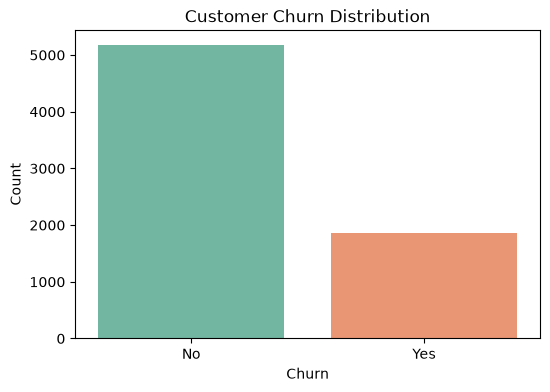

In [6]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Churn', palette='Set2')
plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

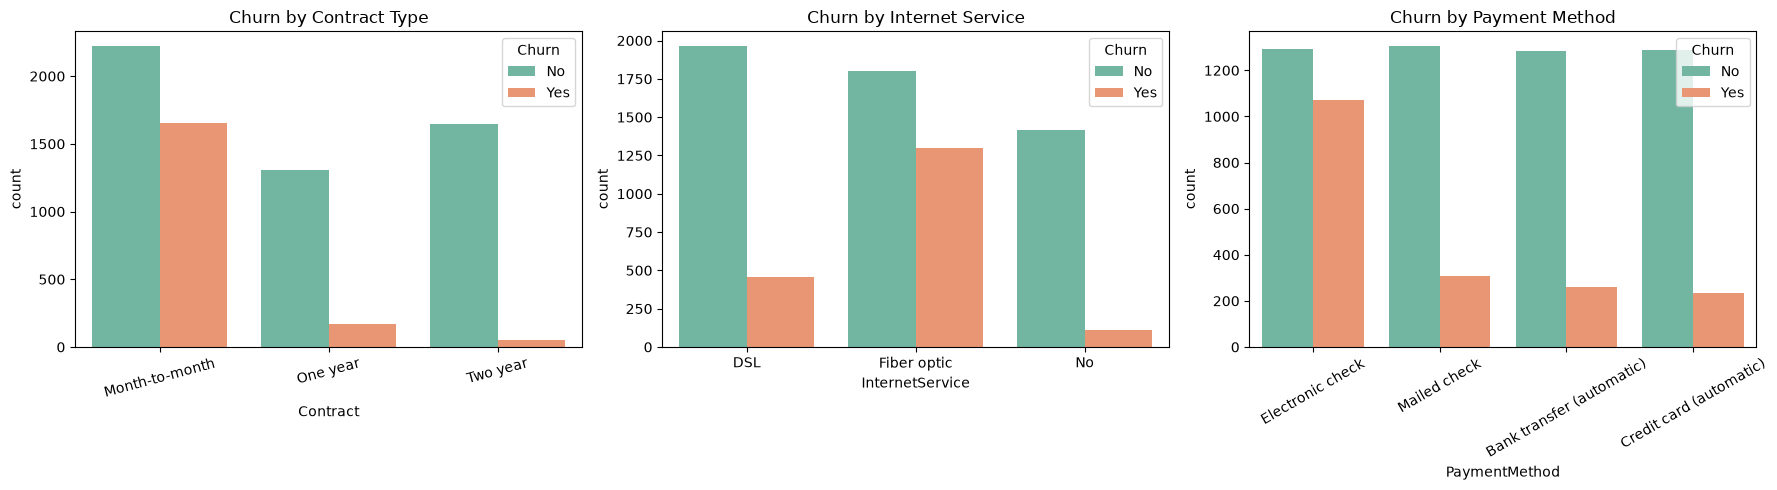

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=df, x='Contract', hue='Churn', ax=axes[0], palette='Set2')
axes[0].set_title('Churn by Contract Type')
axes[0].tick_params(axis='x', rotation=15)

sns.countplot(data=df, x='InternetService', hue='Churn', ax=axes[1], palette='Set2')
axes[1].set_title('Churn by Internet Service')

sns.countplot(data=df, x='PaymentMethod', hue='Churn', ax=axes[2], palette='Set2')
axes[2].set_title('Churn by Payment Method')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

C:\Users\osamakhan\AppData\Local\Temp\ipykernel_5056\104335546.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='tenure', ax=axes[0], palette='Set2')
C:\Users\osamakhan\AppData\Local\Temp\ipykernel_5056\104335546.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[1], palette='Set2')
C:\Users\osamakhan\AppData\Local\Temp\ipykernel_5056\104335546.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='TotalCharges', ax=axes[2], palette='Set2')


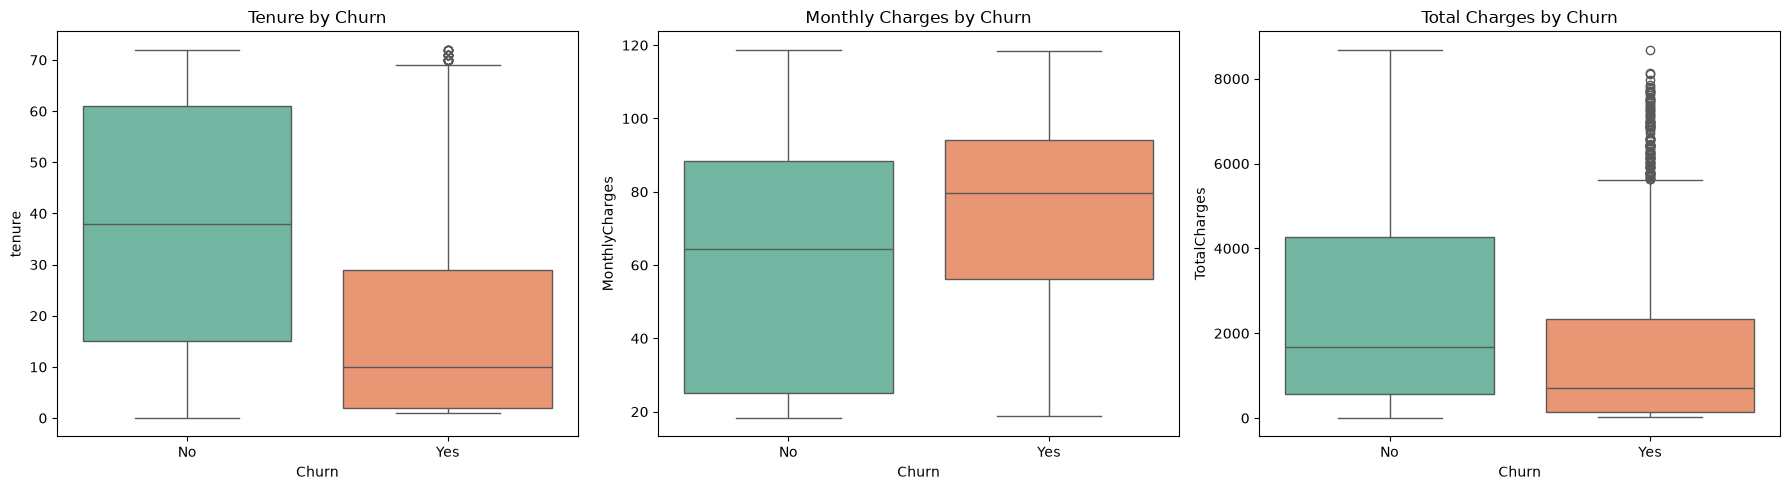

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df, x='Churn', y='tenure', ax=axes[0], palette='Set2')
axes[0].set_title('Tenure by Churn')

sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[1], palette='Set2')
axes[1].set_title('Monthly Charges by Churn')

sns.boxplot(data=df, x='Churn', y='TotalCharges', ax=axes[2], palette='Set2')
axes[2].set_title('Total Charges by Churn')

plt.tight_layout()
plt.show()

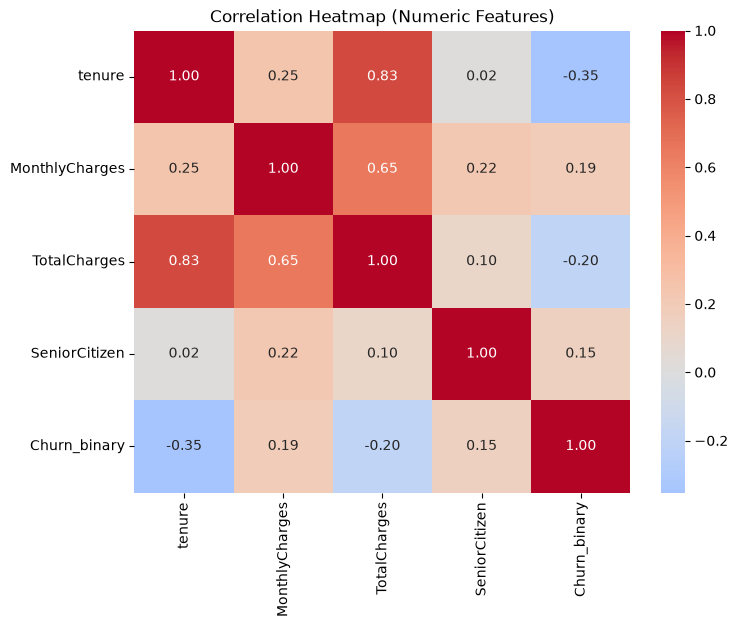

In [9]:
# Create a temporary numeric-only view for correlation
df_corr = df.copy()
df_corr['Churn_binary'] = df_corr['Churn'].map({'Yes': 1, 'No': 0})

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn_binary']

plt.figure(figsize=(8, 6))
sns.heatmap(df_corr[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', center=0)
plt.title('Correlation Heatmap (Numeric Features)')
plt.show()

In [10]:
def tenure_segment(tenure):
    if tenure <= 12:
        return 'New Customer'
    elif tenure <= 48:
        return 'Regular Customer'
    else:
        return 'Loyal Customer'

df['TenureSegment'] = df['tenure'].apply(tenure_segment)

print(df['TenureSegment'].value_counts())
print("\nChurn rate by tenure segment:")
print(df.groupby('TenureSegment')['Churn'].value_counts(normalize=True).unstack() * 100)

TenureSegment
Regular Customer    2618
Loyal Customer      2239
New Customer        2186
Name: count, dtype: int64

Churn rate by tenure segment:
Churn                    No        Yes
TenureSegment                         
Loyal Customer    90.486824   9.513176
New Customer      52.561757  47.438243
Regular Customer  76.355997  23.644003


In [11]:
def spend_category(charge):
    if charge <= 35:
        return 'Low Spend'
    elif charge <= 70:
        return 'Medium Spend'
    else:
        return 'High Spend'

df['SpendCategory'] = df['MonthlyCharges'].apply(spend_category)

print(df['SpendCategory'].value_counts())
print("\nChurn rate by spend category:")
print(df.groupby('SpendCategory')['Churn'].value_counts(normalize=True).unstack() * 100)

SpendCategory
High Spend      3583
Low Spend       1735
Medium Spend    1725
Name: count, dtype: int64

Churn rate by spend category:
Churn                 No        Yes
SpendCategory                      
High Spend     64.638571  35.361429
Low Spend      89.106628  10.893372
Medium Spend   76.057971  23.942029


In [12]:
service_cols = ['PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 
                 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

def count_services(row):
    count = 0
    for col in service_cols:
        if row[col] == 'Yes':
            count += 1
    # InternetService counts as a service if not 'No'
    if row['InternetService'] != 'No':
        count += 1
    return count

df['ServiceCount'] = df.apply(count_services, axis=1)

print(df['ServiceCount'].value_counts().sort_index())
print("\nChurn rate by service count:")
print(df.groupby('ServiceCount')['Churn'].value_counts(normalize=True).unstack() * 100)

ServiceCount
1    1264
2     859
3     846
4     965
5     922
6     908
7     676
8     395
9     208
Name: count, dtype: int64

Churn rate by service count:
Churn                No        Yes
ServiceCount                      
1             89.082278  10.917722
2             69.033760  30.966240
3             55.082742  44.917258
4             63.523316  36.476684
5             68.655098  31.344902
6             74.449339  25.550661
7             77.514793  22.485207
8             87.594937  12.405063
9             94.711538   5.288462


In [13]:
def contract_risk(contract):
    if contract == 'Month-to-month':
        return 3  # High risk
    elif contract == 'One year':
        return 2  # Medium risk
    else:  # Two year
        return 1  # Low risk

df['ContractRiskScore'] = df['Contract'].apply(contract_risk)

print(df['ContractRiskScore'].value_counts().sort_index())
print("\nChurn rate by contract risk score:")
print(df.groupby('ContractRiskScore')['Churn'].value_counts(normalize=True).unstack() * 100)

ContractRiskScore
1    1695
2    1473
3    3875
Name: count, dtype: int64

Churn rate by contract risk score:
Churn                     No        Yes
ContractRiskScore                      
1                  97.168142   2.831858
2                  88.730482  11.269518
3                  57.290323  42.709677


In [14]:
from sklearn.preprocessing import LabelEncoder

binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])
    print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

Partner: {'No': np.int64(0), 'Yes': np.int64(1)}
Dependents: {'No': np.int64(0), 'Yes': np.int64(1)}
PhoneService: {'No': np.int64(0), 'Yes': np.int64(1)}
PaperlessBilling: {'No': np.int64(0), 'Yes': np.int64(1)}
Churn: {'No': np.int64(0), 'Yes': np.int64(1)}


In [15]:
nominal_cols = ['gender', 'InternetService', 'PaymentMethod', 'Contract', 
                 'TenureSegment', 'SpendCategory', 'MultipleLines', 
                 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                 'TechSupport', 'StreamingTV', 'StreamingMovies']

df_encoded = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

print("Shape after encoding:", df_encoded.shape)
print("\nNew columns:")
print(df_encoded.columns.tolist())

Shape after encoding: (7043, 38)

New columns:
['customerID', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'ServiceCount', 'ContractRiskScore', 'gender_Male', 'InternetService_Fiber optic', 'InternetService_No', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'Contract_One year', 'Contract_Two year', 'TenureSegment_New Customer', 'TenureSegment_Regular Customer', 'SpendCategory_Low Spend', 'SpendCategory_Medium Spend', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes']


In [16]:
df_encoded = df_encoded.drop('customerID', axis=1)
print("Shape after dropping customerID:", df_encoded.shape)
print(df_encoded.dtypes.value_counts())

Shape after dropping customerID: (7043, 37)
bool       26
int64       9
float64     2
Name: count, dtype: int64


In [17]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("\nChurn rate in train:", y_train.mean())
print("Churn rate in test:", y_test.mean())

X_train shape: (5634, 36)
X_test shape: (1409, 36)

Churn rate in train: 0.2653532126375577
Churn rate in test: 0.2654364797728886


In [18]:
from sklearn.preprocessing import StandardScaler

scale_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test_scaled[scale_cols] = scaler.transform(X_test[scale_cols])

print(X_train_scaled[scale_cols].describe())

             tenure  MonthlyCharges  TotalCharges
count  5.634000e+03    5.634000e+03  5.634000e+03
mean  -1.008935e-17   -2.402527e-16  2.522338e-17
std    1.000089e+00    1.000089e+00  1.000089e+00
min   -1.322329e+00   -1.544028e+00 -1.008922e+00
25%   -9.559779e-01   -9.711977e-01 -8.321009e-01
50%   -1.418632e-01    1.848336e-01 -3.968446e-01
75%    9.164859e-01    8.319124e-01  6.741944e-01
max    1.608483e+00    1.785939e+00  2.801869e+00


In [19]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

print("Model trained.")
print("Number of features:", X_train_scaled.shape[1])

Model trained.
Number of features: 36


Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.53      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409

ROC-AUC Score: 0.8414


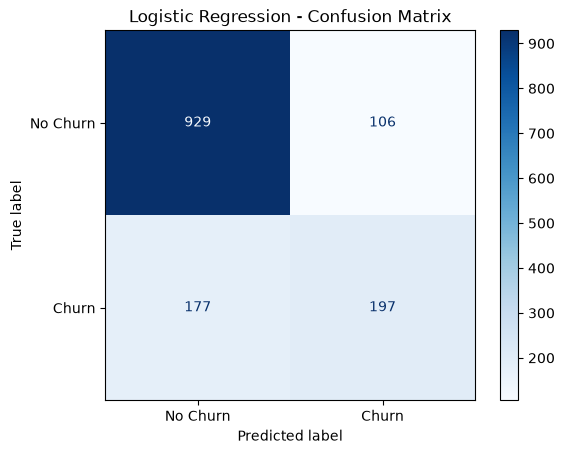

In [20]:
from sklearn.metrics import (classification_report, confusion_matrix, 
                               roc_auc_score, ConfusionMatrixDisplay)

y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred_lr))

roc_auc = roc_auc_score(y_test, y_proba_lr)
print(f"ROC-AUC Score: {roc_auc:.4f}")

cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Blues')
plt.title('Logistic Regression - Confusion Matrix')
plt.show()

In [21]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, class_weight='balanced')
rf.fit(X_train_scaled, y_train)

print("Model trained.")

Model trained.


Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1035
           1       0.53      0.78      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.76      0.77      1409

ROC-AUC Score: 0.8406


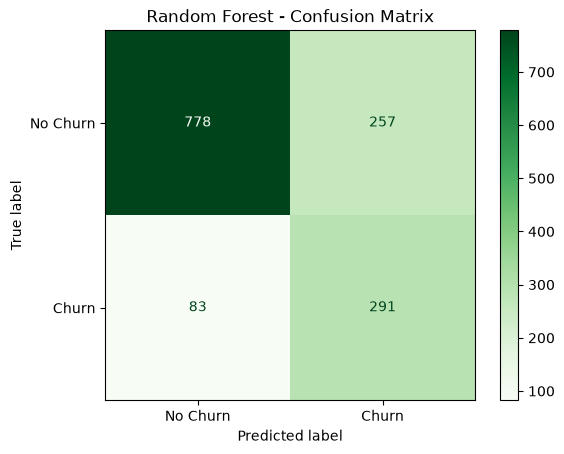

In [22]:
y_pred_rf = rf.predict(X_test_scaled)
y_proba_rf = rf.predict_proba(X_test_scaled)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred_rf))

roc_auc_rf = roc_auc_score(y_test, y_proba_rf)
print(f"ROC-AUC Score: {roc_auc_rf:.4f}")

cm_rf = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Greens')
plt.title('Random Forest - Confusion Matrix')
plt.show()

In [23]:
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)
xgb.fit(X_train_scaled, y_train)

print("Model trained.")
print(f"scale_pos_weight used: {scale_pos_weight:.2f}")

Model trained.
scale_pos_weight used: 2.77


Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1035
           1       0.53      0.76      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.76      0.77      1409

ROC-AUC Score: 0.8362


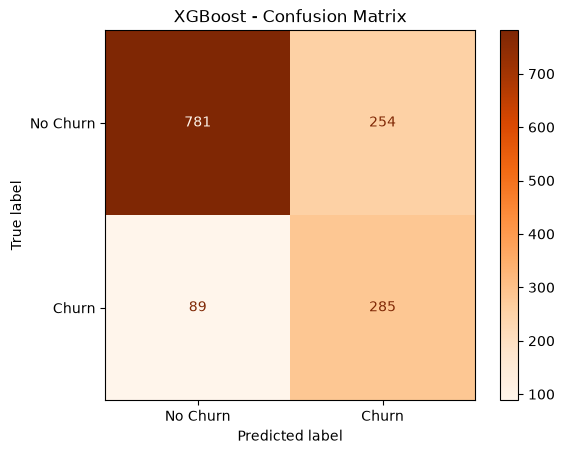

In [24]:
y_pred_xgb = xgb.predict(X_test_scaled)
y_proba_xgb = xgb.predict_proba(X_test_scaled)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred_xgb))

roc_auc_xgb = roc_auc_score(y_test, y_proba_xgb)
print(f"ROC-AUC Score: {roc_auc_xgb:.4f}")

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Oranges')
plt.title('XGBoost - Confusion Matrix')
plt.show()

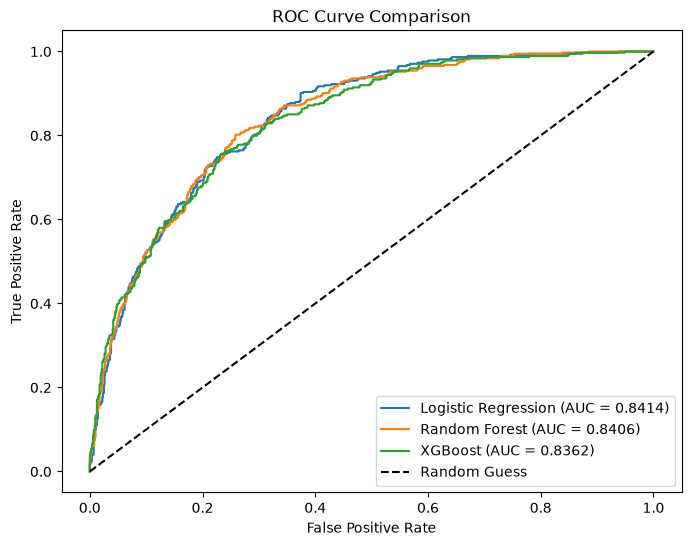

In [25]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 6))

for name, y_proba in [('Logistic Regression', y_proba_lr), 
                        ('Random Forest', y_proba_rf), 
                        ('XGBoost', y_proba_xgb)]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

C:\Users\osamakhan\AppData\Local\Temp\ipykernel_5056\3280914681.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances.head(15), x='Importance', y='Feature', palette='viridis')


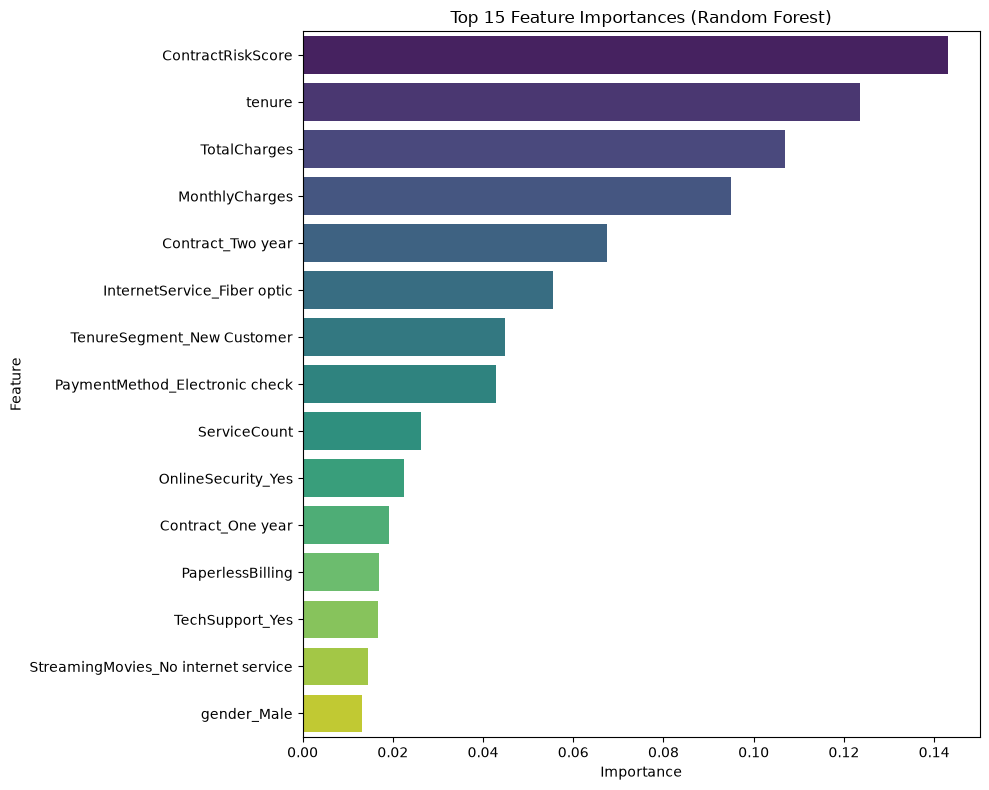

                                Feature  Importance
9                     ContractRiskScore    0.143014
3                                tenure    0.123629
7                          TotalCharges    0.107026
6                        MonthlyCharges    0.095070
17                    Contract_Two year    0.067396
11          InternetService_Fiber optic    0.055544
18           TenureSegment_New Customer    0.044916
14       PaymentMethod_Electronic check    0.042931
8                          ServiceCount    0.026161
25                   OnlineSecurity_Yes    0.022379
16                    Contract_One year    0.019164
5                      PaperlessBilling    0.017023
31                      TechSupport_Yes    0.016632
34  StreamingMovies_No internet service    0.014445
10                          gender_Male    0.013224


In [26]:
importances = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=importances.head(15), x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.tight_layout()
plt.show()

print(importances.head(15))

In [27]:
from sklearn.model_selection import cross_val_score

models = {
    'Logistic Regression': log_reg,
    'Random Forest': rf,
    'XGBoost': xgb
}

for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='roc_auc')
    print(f"{name}: Mean ROC-AUC = {scores.mean():.4f} (+/- {scores.std():.4f})")

Logistic Regression: Mean ROC-AUC = 0.8463 (+/- 0.0142)
Random Forest: Mean ROC-AUC = 0.8427 (+/- 0.0137)
XGBoost: Mean ROC-AUC = 0.8326 (+/- 0.0107)


In [28]:
import joblib

# Save all three trained models
joblib.dump(log_reg, '../models/logistic_regression.pkl')
joblib.dump(rf, '../models/random_forest.pkl')
joblib.dump(xgb, '../models/xgboost_model.pkl')

# Save the scaler (needed to transform new input the same way)
joblib.dump(scaler, '../models/scaler.pkl')

# Save the exact column order/structure the models expect
joblib.dump(X_train_scaled.columns.tolist(), '../models/feature_columns.pkl')

print("All models and preprocessing objects saved successfully.")

All models and preprocessing objects saved successfully.
